# PubHealth Dataset — First Analysis
ASHO-UAB Fake News Prediction Project

In [1]:
# Install dependencies
!pip install datasets pandas matplotlib seaborn -q


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

import pandas as pd

train_df = pd.read_csv('PUBHEALTH/train.tsv', sep='\t')
val_df   = pd.read_csv('PUBHEALTH/dev.tsv',   sep='\t')
test_df  = pd.read_csv('PUBHEALTH/test.tsv',  sep='\t')

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
train_df.head(3)

c:\Users\Agustin51\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 9832 | Val: 1221 | Test: 1235


,claim_id,claim,date_published,explanation,fact_checkers,main_text,sources,label,subjects
0,15661,"""The money the Clinton Foundation took from fr...","April 26, 2015","""Gingrich said the Clinton Foundation """"took m...",Katie Sanders,"""Hillary Clinton is in the political crosshair...",https://www.wsj.com/articles/clinton-foundatio...,false,"Foreign Policy, PunditFact, Newt Gingrich,"
1,9893,Annual Mammograms May Have More False-Positives,"October 18, 2011",This article reports on the results of a study...,,While the financial costs of screening mammogr...,,mixture,"Screening,WebMD,women's health"
2,11358,SBRT Offers Prostate Cancer Patients High Canc...,"September 28, 2016",This news release describes five-year outcomes...,"Mary Chris Jaklevic,Steven J. Atlas, MD, MPH,K...",The news release quotes lead researcher Robert...,https://www.healthnewsreview.org/wp-content/up...,mixture,"Association/Society news release,Cancer"


In [3]:
# Basic info
print(train_df.dtypes)
print("\nMissing values (train):")
print(train_df.isnull().sum())

claim_id          object
claim             object
date_published    object
explanation       object
fact_checkers     object
main_text         object
sources           object
label             object
subjects          object
dtype: object

Missing values (train):
claim_id             0
claim                8
date_published    1937
explanation          8
fact_checkers       11
main_text           26
sources             28
label               27
subjects            28
dtype: int64


## 1. Label Distribution

C:\Users\Agustin51\AppData\Local\Temp\ipykernel_18172\3111586564.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='Set2')
C:\Users\Agustin51\AppData\Local\Temp\ipykernel_18172\3111586564.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='Set2')
C:\Users\Agustin51\AppData\Local\Temp\ipykernel_18172\3111586564.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='Set2')


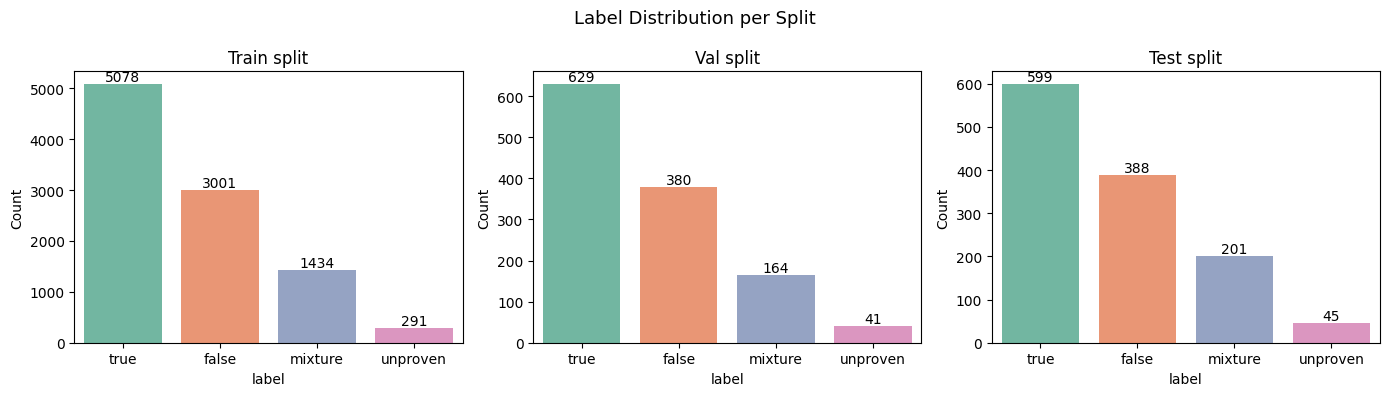

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, df) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    counts = df['label'].value_counts()
    # plot only first 4 labels for better visualization
    counts = counts.head(4)
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='Set2')
    ax.set_title(f'{name} split')
    ax.set_ylabel('Count')
    for p in ax.patches:
        ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.suptitle('Label Distribution per Split', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Text Length Analysis

In [5]:
for col in ['claim', 'main_text', 'explanation']:
    train_df[f'{col}_len'] = train_df[col].fillna('').apply(lambda x: len(x.split()))

train_df[['claim_len', 'main_text_len', 'explanation_len']].describe().round(1)

,claim_len,main_text_len,explanation_len
count,9832.0,9832.0,9832.0
mean,13.9,711.9,77.9
std,15.7,513.2,89.8
min,0.0,0.0,0.0
25%,8.0,377.0,25.0
50%,11.0,607.0,38.0
75%,17.0,914.0,92.0
max,779.0,7067.0,671.0


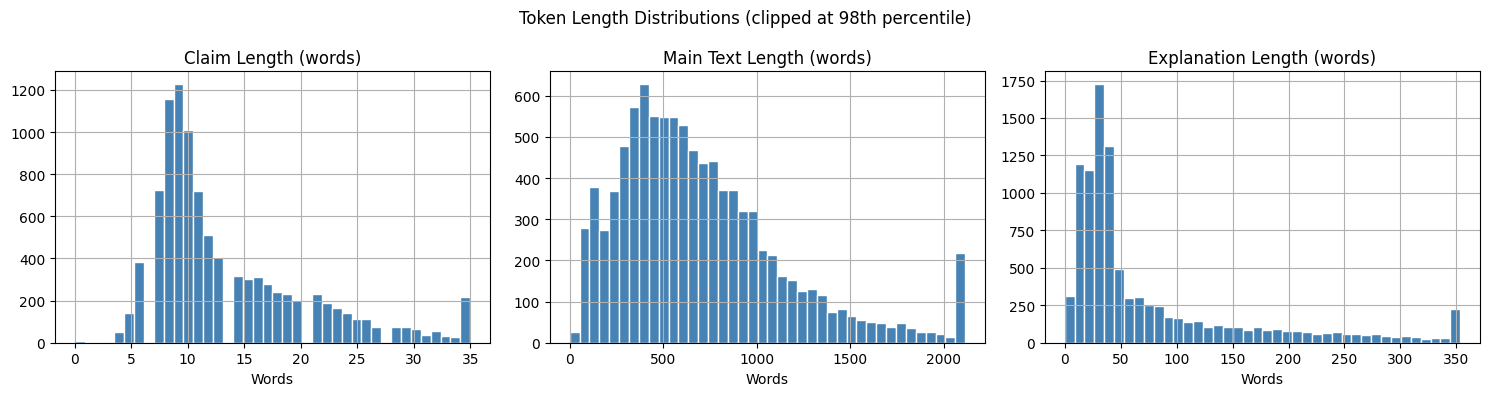

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['claim_len', 'main_text_len', 'explanation_len']):
    train_df[col].clip(upper=train_df[col].quantile(0.98)).hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col.replace('_len', '').replace('_', ' ').title() + ' Length (words)')
    ax.set_xlabel('Words')
plt.suptitle('Token Length Distributions (clipped at 98th percentile)', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Length vs Label

C:\Users\Agustin51\AppData\Local\Temp\ipykernel_18172\1791203149.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='label', y=col, ax=ax, palette='Set2',
C:\Users\Agustin51\AppData\Local\Temp\ipykernel_18172\1791203149.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='label', y=col, ax=ax, palette='Set2',


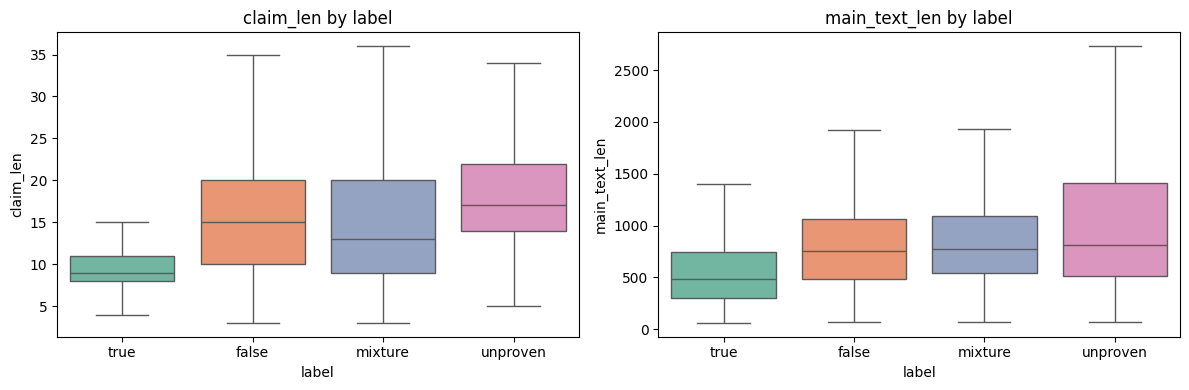

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['claim_len', 'main_text_len']):
    sns.boxplot(data=train_df, x='label', y=col, ax=ax, palette='Set2',
                order=['true','false','mixture','unproven'],
                showfliers=False)
    ax.set_title(f'{col} by label')
plt.tight_layout()
plt.show()

## 4. Missing Data Heatmap

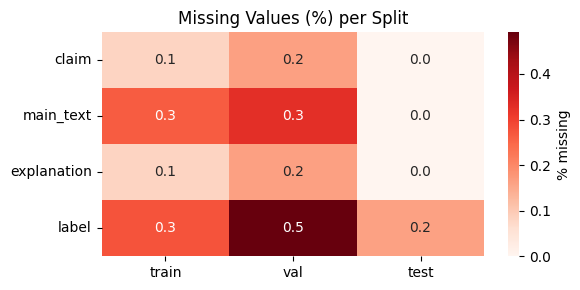

In [9]:
cols_of_interest = ['claim', 'main_text', 'explanation', 'label']
missing = pd.DataFrame({
    split: df[cols_of_interest].isnull().mean() * 100
    for split, df in [('train', train_df), ('val', val_df), ('test', test_df)]
})

plt.figure(figsize=(6, 3))
sns.heatmap(missing, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': '% missing'})
plt.title('Missing Values (%) per Split')
plt.tight_layout()
plt.show()

## 5. Sample Claims per Label

In [10]:
for label in ['true', 'false', 'mixture', 'unproven']:
    sample = train_df[train_df['label'] == label]['claim'].dropna().sample(1, random_state=42).values[0]
    print(f"[{label.upper()}] {sample[:200]}\n")

[TRUE] Part of St. Croix River makes Minnesota impaired waters list.

[FALSE] PEDOPHILIA is now LEGAL in CALIFORNIA. Now a 21 year old can have sex with an 11 year old, and not be listed on the sex registry as a sex offender.

[MIXTURE] By declaring that Pluto was no longer a planet, the (International Astronomical Union) put into place a planetary definition that would have even declassified Earth as a planet if it existed as far fr

[UNPROVEN] "Nearly one out of ten Americans think chocolate milk comes from ""brown cows."

